In [1]:
import gymnasium as gym
import torch
from torch import nn
import torch.optim as optim
from torch.distributions import Normal      # normal dist

import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, stdev
import random

import re, os, json, time
from datetime import datetime
from collections import deque
from tqdm import tqdm

In [2]:
class Actor(nn.Module):
    def __init__(self, obs_dim: int,
                 act_dim: int,
                 act_low, act_high, 
                 hidden_layers=[64,64], 
                 cuda_enabled=False):
        ''' Initialize the model and create a list of layers '''
        super().__init__()

        self.act_low, self.act_high = act_low, act_high

        self.layers = nn.ModuleList()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        # hidden layers
        for layer_size in hidden_layers:
            self.layers.append(nn.Linear(obs_dim, layer_size))
            obs_dim = layer_size
        # output layers
        self.layers.append(nn.Linear(obs_dim, self.act_dim))
        self.tanh = nn.Tanh()

        if cuda_enabled: self.cuda()

    def forward(self, input):
        for layer in self.layers[:-1]:
            input = torch.relu(layer(input))
        output = self.layers[-1](input)
        act_tanh = self.tanh(output)

        # rescale to environment bounds
        act = 0.5 * (act_tanh + 1.0) * (self.act_high - self.act_low) + self.act_low
        return act
    
class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_layers=[32,32], cuda_enabled=False):
        ''' Initialize the model and create a list of layers '''
        super().__init__()

        self.layers = nn.ModuleList()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        
        prev_layer_size = hidden_layers[0]
        self.layers.append(nn.Linear(obs_dim+act_dim,prev_layer_size))
        for layer_size in hidden_layers[1:]:
            self.layers.append(nn.Linear(prev_layer_size, layer_size))
            prev_layer_size = layer_size

        self.layers.append(nn.Linear(prev_layer_size, self.act_dim))
        if cuda_enabled: self.cuda()

    def forward(self, obs, act):
        ''' Return the action value estimates 
        
        Parameters:
        ------------
        obs : [batch_size, obs_dim]
        act : [batch_size, act_dim]
        '''
        input = torch.cat([obs, act], dim=-1)
        for layer in self.layers[:-1]:
            input = torch.relu(layer(input))
        output = self.layers[-1](input)
        return output

In [3]:
model_registry = {
    'TD3_v0': {
        'actor_config': [64,64],
        'critic_config': [64,64]
    },
    'TD3_v1': {
        'actor_config': [128,128],
        'critic_config': [128,128]
    }
}

MODEL_NAME = 'TD3_v0'
ALPHA1 = 5e-3
ALPHA2 = 5e-3
BETA = 5e-3
GAMMA = 0.99
TAU_C = 5e-2
TAU_A = 5e-2
SIGMA = 0.2
CLIP = 0.5

BUFFER_SIZE = 10000
BUFFER_INIT = 1000
BATCH_SIZE = 64

In [4]:
def load_model(q_network: nn.Module, model_path):
    checkpoint = torch.load(model_path)
    q_network.load_state_dict(checkpoint['model_state_dict'])

def EMA_filter(reward: list, alpha):
        ''' Function that runs an exponential moving average filter along a datastream '''
        output = np.zeros(len(reward)+1)
        output[0] = reward[0]
        for idx, item in enumerate(reward):
            output[idx+1] = (1 - alpha) * output[idx] + alpha * item
        
        return output

def plot_fn(history, xlabel:str='step', ylabel: str='reward', alpha: float=0.0):
        ''' Function that plots the reward and filtered reward per episode, then saves the plot in a specified save directory'''
        n_episodes= len(history)
        episodes = range(n_episodes)
        filtered_reward_hist = EMA_filter(history, alpha)

        legend = []
        plt.figure(figsize=(20,6))
        plt.plot(episodes, history[:n_episodes], color = "blue"); legend.append(ylabel)
        if alpha:
            plt.plot(episodes, filtered_reward_hist[:n_episodes], color = "red"); legend.append('filtered '+ylabel)
        # plt.title(f'Total reward per episode - {self.hyperparam_config}')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend(legend)
        plt.grid(which='both')

        plt.tight_layout()
        # if self.save_path:
        #     plt.savefig(os.path.join(self.save_path,'reward_history.png'))
        plt.show()

/home/controlslab/anaconda3/lib/python3.13/site-packages/gymnasium/envs/mujoco/mujoco_env.py:195: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  if np.array(ctrl).shape != (self.model.nu,):


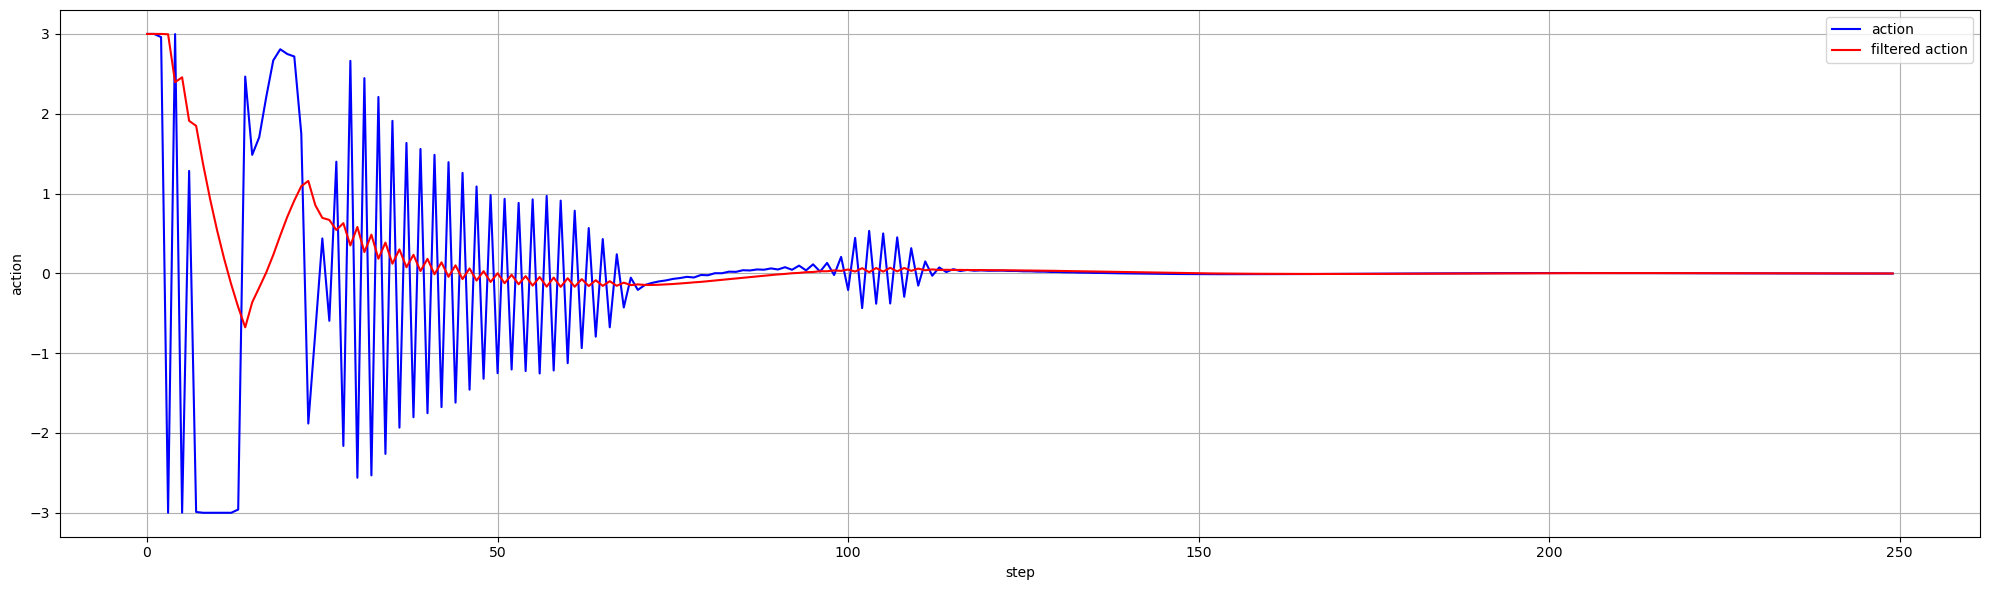

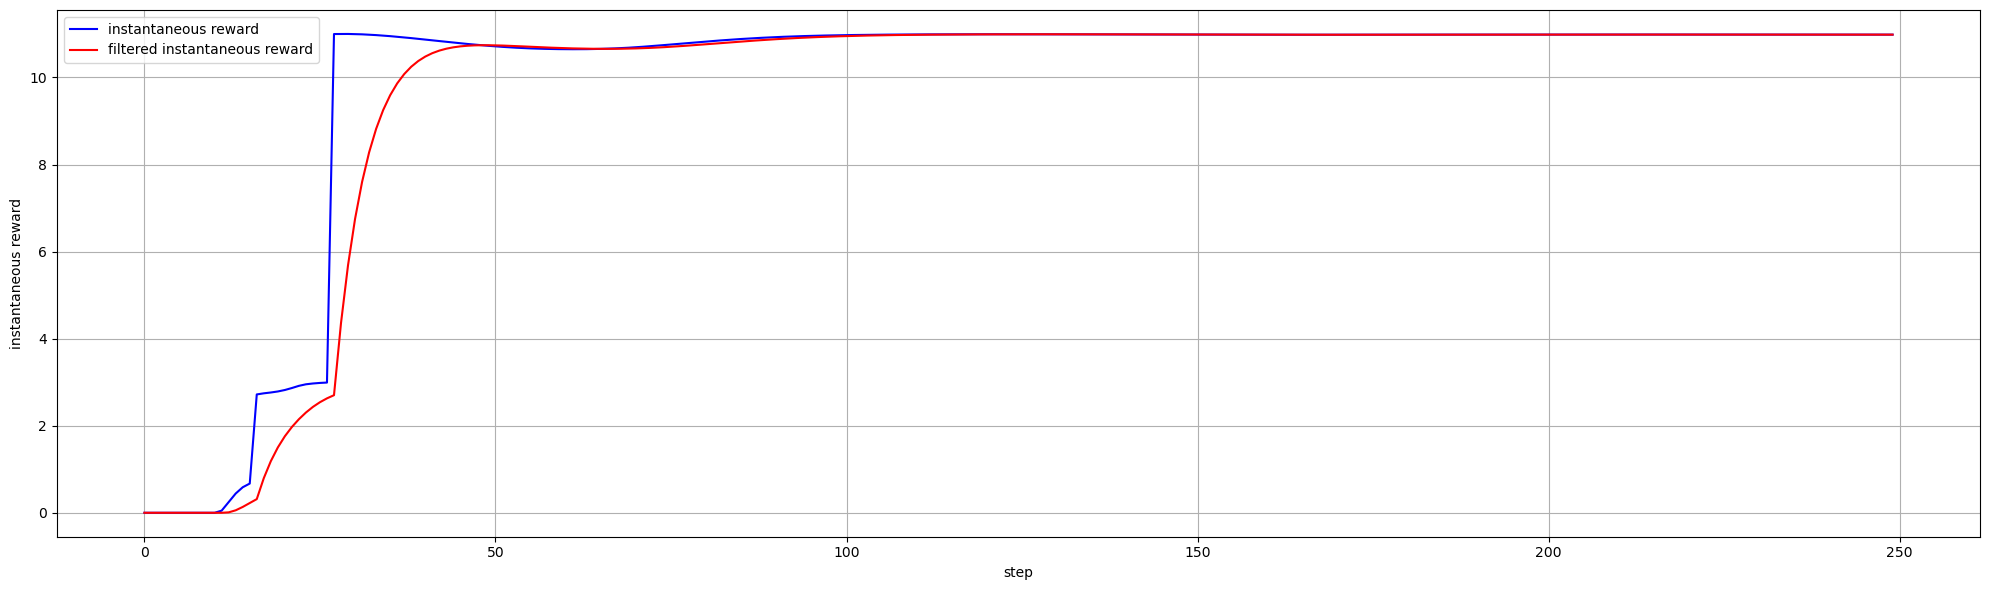

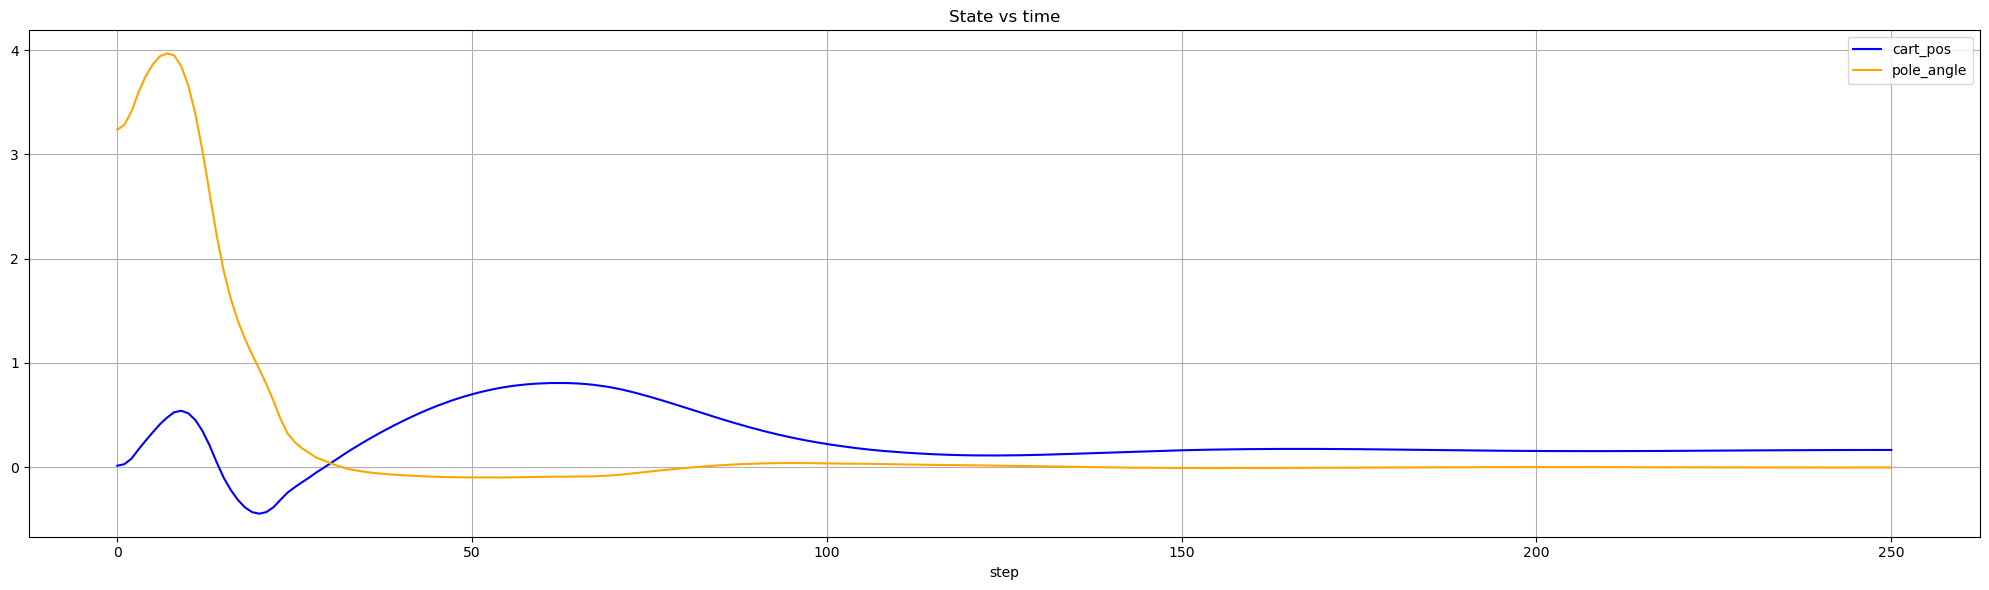

In [5]:
## Manually select a folder/run to load
run_number = 'run_00146'

## Find the paths to the param_config and model checkpoint
# RESULT_DIR = os.path.dirname(REINFORCE_experiment.save_path)    # Can run this after running one experiment
BASE_DIR = os.getcwd()
RESULT_DIR = os.path.join(BASE_DIR,'swingup_TD3_results')
RUN_DIR = os.path.join(RESULT_DIR, run_number)
MODEL_PATH = os.path.join(RUN_DIR,'q_network_checkpoint.pth')

## Find the model configuration
with open(os.path.join(RUN_DIR,"param_config.json"),'r') as f:
    data = json.load(f)
model_name = data['parameters']['model_name']
model_config = model_registry[model_name]['actor_config']

from SwingUp.inv_pend_wrapper import SwingUpInvPenWrapper

width = 1920
height = 1080
default_camera_config = {"azimuth" : 90.0, "elevation" : 0.0, "distance" : 3.5, "lookat" : [0.0, 0.0, 0.25]}

env_test = gym.make('InvertedPendulum-v5', 
               xml_file=os.path.join(os.getcwd(),'SwingUp','inverted_pendulum.xml'),
               render_mode='human',
               width=width,height=height,
               default_camera_config=default_camera_config)
env_test = SwingUpInvPenWrapper(env_test, train=False)
# print(env_test.train)
obs_space = env_test.observation_space.shape[0]
act_space = env_test.action_space.shape[0]
act_low = torch.as_tensor(env_test.action_space.low, dtype=torch.float32, device = 'cpu')
act_high = torch.as_tensor(env_test.action_space.high, dtype=torch.float32, device = 'cpu')

# Create the model according to the model version in the model registry
policy_net= Actor(obs_space, act_space, 
                    act_low=act_low, act_high=act_high, 
                    hidden_layers=model_config)
load_model(policy_net, MODEL_PATH)

act_hist = []
rew_hist = []
cartp_hist = []
polep_hist = []

obs, _ = env_test.reset()
cartp_hist.append(obs[0])
polep_hist.append(obs[1])

noise_std = 0

for _ in range(250):
    with torch.no_grad():
        obs_t = torch.as_tensor(obs, dtype = torch.float32, device = 'cpu')
        act = policy_net(obs_t)
        act += torch.randn_like(act) * noise_std

        nobs, rew, term, trunc, _ = env_test.step(act)
        cartp_hist.append(nobs[0])
        polep_hist.append(nobs[1])
        # print(f"Time {t:2d}  |  s_t {obs}  |  a_t {action.item(): 2.5f}  |  reward {rew} |  s_t+1 {nobs} | term {term}")

        act_hist.append(act)
        rew_hist.append(rew)

        done = term or trunc
        if not done:
            obs = nobs  
        else:
            obs = env_test.reset()[0]
            if term:
                act_hist = []
                rew_hist = []
                cartp_hist = []
                polep_hist = []

env_test.close()

plot_fn(act_hist, ylabel='action', alpha=0.1)
plot_fn(rew_hist, ylabel='instantaneous reward', alpha=0.2)

plt.figure(figsize=(20,6))

plt.plot(range(len(cartp_hist)), cartp_hist, color = "blue")
plt.plot(range(len(polep_hist)), polep_hist, color = "orange")
plt.title("State vs time"); plt.xlabel('step')
plt.legend(["cart_pos", "pole_angle"])
plt.grid(which='both')
plt.tight_layout()
plt.show()
